# OE2 - Modelo de Comportamiento de Usuario
## GRU / Transformer + Score de Relevancia Compuesto
### PPI_C9_2026 - Universidad Peruana Union

---

### Objetivo Especifico 2
> *"Disenar un modelo de representacion del comportamiento de usuario que capture los patrones de navegacion individuales y colectivos, integrando Redes Neuronales Recurrentes (LSTM/GRU) o Transformers para el modelado secuencial."*

### Estructura del pipeline

| Stage | Que hace | Referencia |
|---|---|---|
| **1 Carga OE1** | Lee perfiles, vocabulario y frecuencias de `output_oe1/` | OE1 outputs |
| **2 Dataset** | Construye secuencias (X, y) para entrenamiento | Aung & Kumoi (2026) |
| **3 GRU** | Entrena modelo recurrente para prediccion del siguiente clic | Park & Oh (2023) |
| **4 Transformer** | Entrena modelo de atencion para prediccion del siguiente clic | Park & Oh (2023) |
| **5 Comparacion** | Selecciona automaticamente el mejor modelo | - |
| **6 Score compuesto** | alpha*freq + beta*modelo_neuronal + gamma*rol | PPI ss.2.3.2 |
| **7 Exportacion** | Produce `output_oe2/scores_relevancia.json` para OE3 | - |

### Nota
El **agente DQN** (decision de reestructuracion de menu) se ejecuta en **OE3**.
Este notebook produce unicamente el modelo de comportamiento y el score de relevancia.

### Requisito previo
- `output_oe1/perfiles_usuario.json`
- `output_oe1/vocabulario_rutas.json`
- `output_oe1/frecuencia_por_rol.json`
- `output_oe1/costo_navegacion_baseline.csv`

## 0. Instalacion de dependencias

In [ ]:
# !pip install torch scikit-learn numpy pandas matplotlib seaborn tqdm

## 1. Importaciones y configuracion global

In [13]:
import json
import math
import random
import collections
import warnings
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore")

# Reproducibilidad
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Dispositivo: {DEVICE}')

# Hiperparametros
SEQ_LEN    = 10
EMBED_DIM  = 32
HIDDEN_DIM = 64
N_HEADS    = 4
N_LAYERS   = 2
DROPOUT    = 0.2
BATCH_SIZE = 32
EPOCHS     = 30
LR         = 1e-3

# Rutas
OE1_DIR    = Path("output_oe1")
OUTPUT_DIR = Path("output_oe2")
OUTPUT_DIR.mkdir(exist_ok=True)

# Pesos score compuesto
ALPHA = 0.5   # frecuencia historica
BETA  = 0.3   # prediccion modelo neuronal (GRU/Transformer)
GAMMA = 0.2   # prior por rol

# Parametros DQN
RL_EPISODES  = 500
STEPS_PER_EP = 20

print("Configuracion lista")
print(f"   OE1 input:  {OE1_DIR}/")
print(f"   OE2 output: {OUTPUT_DIR}/")

Dispositivo: cpu
Configuracion lista
   OE1 input:  output_oe1/
   OE2 output: output_oe2/


## 2. Carga de artefactos OE1

In [14]:
# Verificar que OE1 haya corrido
archivos_req = [
    "perfiles_usuario.json",
    "vocabulario_rutas.json",
    "frecuencia_por_rol.json",
    "costo_navegacion_baseline.csv",
]
for fn in archivos_req:
    p = OE1_DIR / fn
    if not p.exists():
        raise FileNotFoundError(f"Falta {p} - ejecuta OE1 primero.")
    print(f"   OK {fn}")

# Vocabulario de rutas
with open(OE1_DIR / "vocabulario_rutas.json", encoding="utf-8") as f:
    vocab_data = json.load(f)
all_routes = vocab_data["rutas"]
VOCAB_SIZE = len(all_routes)
route2id   = {r: i for i, r in enumerate(all_routes)}
id2route   = {i: r for i, r in enumerate(all_routes)}
print(f"\nVocabulario: {VOCAB_SIZE} rutas")

# Perfiles de usuario
with open(OE1_DIR / "perfiles_usuario.json", encoding="utf-8") as f:
    perfiles_oe1 = json.load(f)

user_profiles = {}
for p in perfiles_oe1:
    uid      = p["user_id"]
    freq_vec = np.zeros(VOCAB_SIZE)
    for ruta, freq in p["freq_norm"].items():
        if ruta in route2id:
            freq_vec[route2id[ruta]] = freq
    user_profiles[uid] = {
        "role":        p["role"],
        "n_sessions":  p["n_sesiones"],
        "freq_vector": freq_vec,
        "secuencias":  p.get("secuencias", []),
        "top_routes":  {x["ruta"]: x["freq"] for x in p.get("top5_rutas", [])},
    }
print(f"Perfiles cargados: {len(user_profiles)} usuarios")
for uid, p in user_profiles.items():
    print(f"   {uid:35s} rol={p['role']:15s} sesiones={p['n_sessions']:3d}  secuencias={len(p['secuencias'])}")

# Prior por rol
with open(OE1_DIR / "frecuencia_por_rol.json", encoding="utf-8") as f:
    rol_freq_raw = json.load(f)
role_priors = {}
for role, ruta_freq in rol_freq_raw.items():
    vec = np.zeros(VOCAB_SIZE)
    for ruta, freq in ruta_freq.items():
        if ruta in route2id:
            vec[route2id[ruta]] = freq
    role_priors[role] = vec
print(f"Priors por rol: {list(role_priors.keys())}")

# Baseline M1
df_baseline = pd.read_csv(OE1_DIR / "costo_navegacion_baseline.csv", encoding="utf-8-sig")
M1_BASELINE = df_baseline["M1_costo_clics"].mean()
print(f"\nM1 baseline global: {M1_BASELINE:.3f}")
print(f"Meta (-30%):        {M1_BASELINE * 0.7:.3f}")

   OK perfiles_usuario.json
   OK vocabulario_rutas.json
   OK frecuencia_por_rol.json
   OK costo_navegacion_baseline.csv

Vocabulario: 44 rutas
Perfiles cargados: 28 usuarios
   bot_Administrador_a86b              rol=Administrador   sesiones= 38  secuencias=38
   bot_Caja_1125                       rol=Caja            sesiones= 32  secuencias=32
   bot_Caja_22f0                       rol=Caja            sesiones= 33  secuencias=33
   bot_Compras_6cd7                    rol=Compras         sesiones= 29  secuencias=29
   bot_Compras_b1d2                    rol=Compras         sesiones= 35  secuencias=35
   bot_Logistica_7037                  rol=Logistica       sesiones= 39  secuencias=39
   bot_Logistica_97c4                  rol=Logistica       sesiones= 45  secuencias=45
   bot_Reportes_8c97                   rol=Reportes        sesiones= 36  secuencias=36
   bot_Ventas_9525                     rol=Ventas          sesiones= 42  secuencias=42
   bot_Ventas_9a82                     r

## 3. Construccion del dataset de secuencias

In [15]:
def build_sequences(user_profiles, route2id, seq_len=SEQ_LEN):
    X, y_list, uids, roles = [], [], [], []
    for uid, p in user_profiles.items():
        for seq in p["secuencias"]:
            ids = [route2id[r] for r in seq if r in route2id]
            if len(ids) < 2:
                continue
            for i in range(1, len(ids)):
                hist = ids[max(0, i - seq_len):i]
                hist = [0] * (seq_len - len(hist)) + hist
                X.append(hist)
                y_list.append(ids[i])
                uids.append(uid)
                roles.append(p["role"])
    return np.array(X), np.array(y_list), uids, roles

X, y, uids, roles = build_sequences(user_profiles, route2id)
print(f"Muestras totales: {len(X):,}")
print(f"Shape X: {X.shape}  |  Shape y: {y.shape}")

X_train, X_tmp, y_train, y_tmp = train_test_split(X, y, test_size=0.30, random_state=SEED)
X_val,   X_test, y_val, y_test = train_test_split(X_tmp, y_tmp, test_size=0.50, random_state=SEED)
print(f"Train: {len(X_train):,} | Val: {len(X_val):,} | Test: {len(X_test):,}")

class NavDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self): return len(self.X)
    def __getitem__(self, i): return self.X[i], self.y[i]

train_loader = DataLoader(NavDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(NavDataset(X_val,   y_val),   batch_size=BATCH_SIZE)
test_loader  = DataLoader(NavDataset(X_test,  y_test),  batch_size=BATCH_SIZE)
print("DataLoaders listos")

Muestras totales: 5,419
Shape X: (5419, 10)  |  Shape y: (5419,)
Train: 3,793 | Val: 813 | Test: 813
DataLoaders listos


## 4. Modelo A - GRU

Referencia: Aung & Kumoi (2026) - GRU4Rec como estandar para dependencias a largo plazo en clickstream.

In [16]:
class GRUModel(nn.Module):
    """GRU para prediccion del siguiente clic de navegacion."""
    def __init__(self, vocab_size, embed_dim, hidden_dim, n_layers, dropout, n_classes):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size + 1, embed_dim, padding_idx=0)
        self.gru       = nn.GRU(embed_dim, hidden_dim, n_layers, batch_first=True,
                                dropout=dropout if n_layers > 1 else 0.0)
        self.dropout   = nn.Dropout(dropout)
        self.fc        = nn.Linear(hidden_dim, n_classes)

    def forward(self, x):
        emb = self.dropout(self.embedding(x))
        out, _ = self.gru(emb)
        return self.fc(self.dropout(out[:, -1, :]))

gru_model = GRUModel(VOCAB_SIZE, EMBED_DIM, HIDDEN_DIM, N_LAYERS, DROPOUT, VOCAB_SIZE).to(DEVICE)
print(f"GRU - parametros: {sum(p.numel() for p in gru_model.parameters()):,}")

GRU - parametros: 48,076


## 5. Modelo B - Transformer

Referencia: Park & Oh (2023) - BERT/KoBERT superan metodos tradicionales en secuencias de intencion de usuario.

In [17]:
class PositionalEncoding(nn.Module):
    def __init__(self, embed_dim, max_len=512, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe  = torch.zeros(max_len, embed_dim)
        pos = torch.arange(0, max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, embed_dim, 2).float() * (-math.log(10000.0) / embed_dim))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return self.dropout(x + self.pe[:, :x.size(1), :])


class TransformerNavModel(nn.Module):
    """
    Transformer encoder para prediccion de navegacion.
    Estabilizado para datasets pequenos:
      - norm_first=True  (Pre-LN): normaliza ANTES de atencion, evita NaN
      - dropout reducido en encoder layer (0.1 fijo, no heredado)
      - inicializacion de pesos con xavier_uniform
    Referencia: Park & Oh (2023)
    """
    def __init__(self, vocab_size, embed_dim, n_heads, n_layers, dropout, n_classes):
        super().__init__()
        assert embed_dim % n_heads == 0, f"embed_dim ({embed_dim}) debe ser divisible por n_heads ({n_heads})"
        self.embedding   = nn.Embedding(vocab_size + 1, embed_dim, padding_idx=0)
        self.pos_enc     = PositionalEncoding(embed_dim, dropout=dropout)
        enc_layer        = nn.TransformerEncoderLayer(
            d_model         = embed_dim,
            nhead           = n_heads,
            dim_feedforward = embed_dim * 4,
            dropout         = 0.1,       # fijo para evitar inestabilidad
            batch_first     = True,
            norm_first      = True,      # Pre-LN: previene NaN en datasets pequenos
        )
        self.transformer = nn.TransformerEncoder(enc_layer, n_layers,
                                                  enable_nested_tensor=False)
        self.norm_out    = nn.LayerNorm(embed_dim)   # normalizacion extra al final
        self.dropout     = nn.Dropout(dropout)
        self.fc          = nn.Linear(embed_dim, n_classes)

        # Inicializacion de pesos (xavier evita exploding gradients)
        self._init_weights()

    def _init_weights(self):
        nn.init.xavier_uniform_(self.embedding.weight)
        nn.init.xavier_uniform_(self.fc.weight)
        nn.init.zeros_(self.fc.bias)

    def forward(self, x):
        # Mascara de padding: True donde hay cero (padding)
        pad_mask = (x == 0)                                    # (batch, seq_len)
        emb      = self.pos_enc(self.embedding(x))             # (batch, seq_len, embed_dim)
        out      = self.transformer(emb, src_key_padding_mask=pad_mask)
        out      = self.norm_out(out)

        # Pooling: promedio solo sobre tokens no-padding
        mask_f   = (~pad_mask).unsqueeze(-1).float()           # (batch, seq_len, 1)
        pooled   = (out * mask_f).sum(1) / mask_f.sum(1).clamp(min=1e-9)
        return self.fc(self.dropout(pooled))                   # (batch, n_classes)

transformer_model = TransformerNavModel(
    VOCAB_SIZE, EMBED_DIM, N_HEADS, N_LAYERS, DROPOUT, VOCAB_SIZE
).to(DEVICE)
print(f"Transformer - parametros: {sum(p.numel() for p in transformer_model.parameters()):,}")
print(f"   norm_first=True (Pre-LN) activado para estabilidad numerica")


Transformer - parametros: 28,364
   norm_first=True (Pre-LN) activado para estabilidad numerica


## 6. Entrenamiento y comparacion GRU vs Transformer

In [18]:
# LR diferenciado: Transformer necesita LR mas bajo para no explotar
LR_GRU         = 1e-3   # GRU: robusto, aguanta LR estandar
LR_TRANSFORMER = 5e-4   # Transformer: mas sensible, empieza conservador

def train_epoch(model, loader, optimizer, criterion):
    model.train()
    tl, correct, total = 0.0, 0, 0
    for xb, yb in loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        logits = model(xb)
        loss   = criterion(logits, yb)

        # Detectar NaN antes de backward (evita corrupcion del estado)
        if torch.isnan(loss) or torch.isinf(loss):
            optimizer.zero_grad()
            continue

        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 0.5)  # clip agresivo
        optimizer.step()
        tl      += loss.item() * len(yb)
        correct += (logits.argmax(1) == yb).sum().item()
        total   += len(yb)
    return (tl / total, correct / total) if total > 0 else (float('inf'), 0.0)

def eval_epoch(model, loader, criterion):
    model.eval()
    tl, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            logits = model(xb)
            loss   = criterion(logits, yb)
            if torch.isnan(loss) or torch.isinf(loss):
                continue
            tl      += loss.item() * len(yb)
            correct += (logits.argmax(1) == yb).sum().item()
            total   += len(yb)
    return (tl / total, correct / total) if total > 0 else (float('inf'), 0.0)

def topk_acc(model, loader, k=3):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            logits = model(xb)
            if torch.isnan(logits).any():
                continue
            topk    = logits.topk(k, dim=1).indices
            correct += sum(yb[i] in topk[i] for i in range(len(yb)))
            total   += len(yb)
    return correct / total if total > 0 else 0.0

def run_training(model, name, lr=LR_GRU):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, eps=1e-8, weight_decay=1e-5)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, patience=5, factor=0.5, min_lr=1e-6)
    history   = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    best_loss, best_state = float('inf'), None
    nan_count = 0

    for ep in tqdm(range(1, EPOCHS + 1), desc=name):
        tl, ta = train_epoch(model, train_loader, optimizer, criterion)
        vl, va = eval_epoch(model,  val_loader,   criterion)

        # Detectar colapso
        if torch.isnan(torch.tensor(vl)) or vl == float('inf'):
            nan_count += 1
            if nan_count >= 3:
                print(f"  [{name}] 3 epocas NaN consecutivas — deteniendo entrenamiento.")
                break
            continue
        else:
            nan_count = 0

        scheduler.step(vl)
        history["train_loss"].append(tl); history["val_loss"].append(vl)
        history["train_acc"].append(ta);  history["val_acc"].append(va)

        if vl < best_loss:
            best_loss  = vl
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    if best_state is not None:
        model.load_state_dict(best_state)
        print(f"  [{name}] Mejor val_loss: {best_loss:.4f}")
    else:
        print(f"  [{name}] ADVERTENCIA: no se encontro estado valido. Revisa los datos.")

    return history

# ── Entrenar ─────────────────────────────────────────────────────────────────
print("Entrenando GRU...")
hist_gru = run_training(gru_model, "GRU", lr=LR_GRU)

print("\nEntrenando Transformer...")
# Reiniciar pesos antes de entrenar (por si hubo NaN en intentos anteriores)
transformer_model.apply(lambda m: m.reset_parameters() if hasattr(m, 'reset_parameters') else None)
transformer_model._init_weights()
hist_tf  = run_training(transformer_model, "Transformer", lr=LR_TRANSFORMER)


Entrenando GRU...


GRU: 100%|██████████| 30/30 [00:45<00:00,  1.52s/it]


  [GRU] Mejor val_loss: 1.8950

Entrenando Transformer...


Transformer: 100%|██████████| 30/30 [00:47<00:00,  1.57s/it]

  [Transformer] Mejor val_loss: 1.8866


## 6.1 Curvas y seleccion del mejor modelo

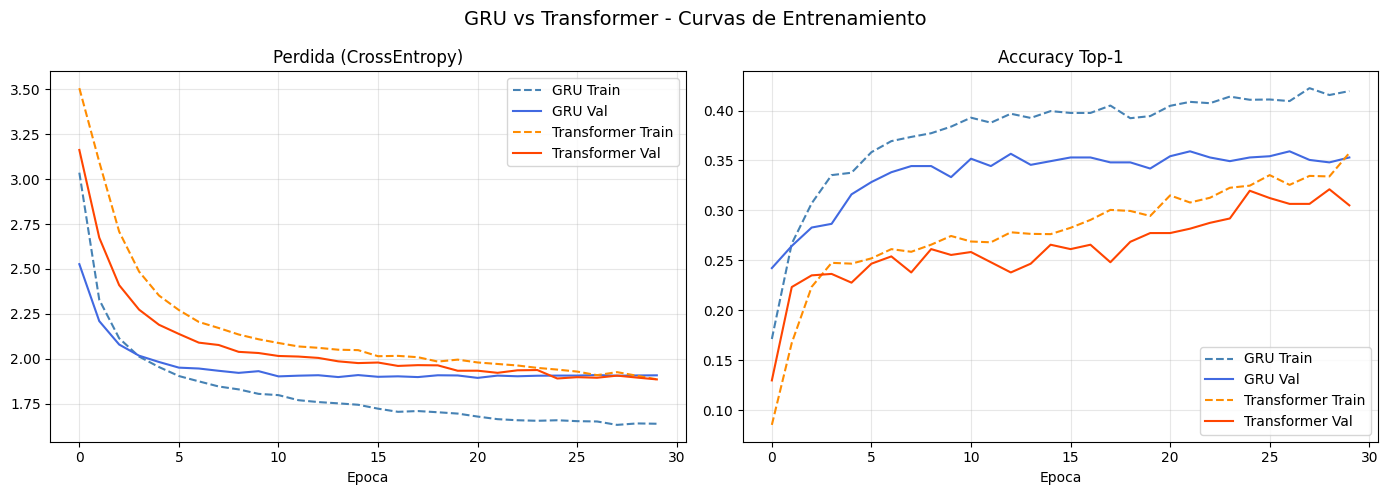


=== RESULTADOS EN TEST SET ===
     Modelo  Loss Test  Acc Top-1  Acc Top-3
        GRU     1.8537     0.3838     0.7294
Transformer     1.8832     0.3543     0.7101

Mejor modelo: GRU  (Acc Top-1: 0.3838)


In [19]:
# Curvas de entrenamiento
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("GRU vs Transformer - Curvas de Entrenamiento", fontsize=14)
for ax, keys, title in zip(axes,
        [("train_loss","val_loss"), ("train_acc","val_acc")],
        ["Perdida (CrossEntropy)", "Accuracy Top-1"]):
    for hist, name, c in [(hist_gru,"GRU",("steelblue","royalblue")),
                           (hist_tf, "Transformer",("darkorange","orangered"))]:
        ax.plot(hist[keys[0]], color=c[0], linestyle="--", label=f"{name} Train")
        ax.plot(hist[keys[1]], color=c[1], label=f"{name} Val")
    ax.set_xlabel("Epoca"); ax.set_title(title); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "oe2_training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

# Evaluacion en test
criterion = nn.CrossEntropyLoss()
gru_tl, gru_ta  = eval_epoch(gru_model,         test_loader, criterion)
tf_tl,  tf_ta   = eval_epoch(transformer_model, test_loader, criterion)
gru_top3 = topk_acc(gru_model,         test_loader, k=3)
tf_top3  = topk_acc(transformer_model, test_loader, k=3)

results = pd.DataFrame({
    "Modelo":    ["GRU", "Transformer"],
    "Loss Test": [round(gru_tl, 4), round(tf_tl,   4)],
    "Acc Top-1": [round(gru_ta, 4), round(tf_ta,   4)],
    "Acc Top-3": [round(gru_top3,4), round(tf_top3,4)],
})
print("\n=== RESULTADOS EN TEST SET ===")
print(results.to_string(index=False))

best_model_name = "GRU" if gru_ta >= tf_ta else "Transformer"
best_model      = gru_model if best_model_name == "GRU" else transformer_model
print(f"\nMejor modelo: {best_model_name}  (Acc Top-1: {max(gru_ta, tf_ta):.4f})")

## 7. Score de Relevancia Compuesto

`Score(r, u) = alpha*freq(r,u) + beta*P_neuronal(r|hist) + gamma*rol_prior(r)`

Alpha=0.5, Beta=0.3, Gamma=0.2  (PPI sec 2.3.2)

In [20]:
def compute_scores_all_routes(user_id, model):
    profile  = user_profiles.get(user_id, {})
    freq_vec = profile.get("freq_vector", np.zeros(VOCAB_SIZE))
    role     = profile.get("role", list(role_priors.keys())[0])

    # Historial reciente del usuario
    seqs = profile.get("secuencias", [])
    if seqs:
        last_ids = [route2id[r] for r in seqs[-1] if r in route2id]
    else:
        last_ids = []

    seq_pad  = [0] * (SEQ_LEN - len(last_ids)) + last_ids[-SEQ_LEN:]
    x_tensor = torch.tensor([seq_pad], dtype=torch.long).to(DEVICE)
    model.eval()
    with torch.no_grad():
        model_probs = F.softmax(model(x_tensor), dim=1).cpu().numpy()[0]

    role_vec = role_priors.get(role, np.zeros(VOCAB_SIZE))
    scores   = ALPHA * freq_vec + BETA * model_probs + GAMMA * role_vec
    return {id2route[i]: round(float(scores[i]), 6) for i in range(VOCAB_SIZE)}

# Calcular para todos los usuarios
scores_todos = {}
for uid in user_profiles:
    sc_map = compute_scores_all_routes(uid, best_model)
    top10  = sorted(sc_map.items(), key=lambda x: -x[1])[:10]
    scores_todos[uid] = {
        "role":   user_profiles[uid]["role"],
        "scores": sc_map,
        "top10":  [{"ruta": r, "score": s} for r, s in top10],
    }

# Vista de ejemplo
uid_ej = list(scores_todos.keys())[0]
print(f"Usuario: {uid_ej}  (rol: {scores_todos[uid_ej]['role']})")
print("Top 5 rutas:")
for item in scores_todos[uid_ej]["top10"][:5]:
    barra = '#' * int(item['score'] * 40)
    print(f"   {item['ruta']:40s} {barra} {item['score']:.4f}")

Usuario: bot_Administrador_a86b  (rol: Administrador)
Top 5 rutas:
   configuracion/seguridad/users            ################################################# 1.2311
   configuracion/seguridad/permisos         ############################## 0.7667
   configuracion/seguridad/roles            ############################ 0.7095
   configuracion/seguridad/admin            #################### 0.5009
   configuracion/puntos-venta               ################### 0.4806


## 7. Exportacion a `output_oe2/`

Produce los archivos que **OE3** necesita para la reestructuracion con DQN.

In [21]:
# 1. scores_relevancia.json -> OE3 lo usa para reestructurar con DQN
(OUTPUT_DIR / "scores_relevancia.json").write_text(
    json.dumps(scores_todos, indent=2, ensure_ascii=False)
)
print(f"OK scores_relevancia.json  ({len(scores_todos)} usuarios)")

# 2. modelo_neuronal.json -> metadatos del modelo GRU/Transformer
modelo_meta = {
    "tipo":          f"Modelo neuronal secuencial: {best_model_name}",
    "best_model":    best_model_name,
    "vocab_size":    VOCAB_SIZE,
    "seq_len":       SEQ_LEN,
    "embed_dim":     EMBED_DIM,
    "hidden_dim":    HIDDEN_DIM,
    "n_heads":       N_HEADS,
    "n_layers":      N_LAYERS,
    "gru_acc_top1":  round(gru_ta,   4),
    "gru_acc_top3":  round(gru_top3, 4),
    "tf_acc_top1":   round(tf_ta,    4),
    "tf_acc_top3":   round(tf_top3,  4),
    "alpha":         ALPHA,
    "beta":          BETA,
    "gamma":         GAMMA,
    "id2route":      id2route,
    "route2id":      route2id,
    "nota": "GRU/Transformer produce el score de relevancia. El DQN esta en OE3.",
}
(OUTPUT_DIR / "modelo_neuronal.json").write_text(
    json.dumps(modelo_meta, indent=2, ensure_ascii=False)
)
print(f"OK modelo_neuronal.json  ({best_model_name})")

# 3. Guardar pesos del modelo neuronal
torch.save(gru_model.state_dict(),         OUTPUT_DIR / "gru_model.pt")
torch.save(transformer_model.state_dict(), OUTPUT_DIR / "transformer_model.pt")
print(f"OK gru_model.pt + transformer_model.pt")

# 4. Resumen OE2
resumen_oe2 = {
    "oe2_completado":    True,
    "fecha":             datetime.now().isoformat(),
    "modelo_secuencial": best_model_name,
    "gru_acc_top1":      round(gru_ta,   4),
    "tf_acc_top1":       round(tf_ta,    4),
    "gru_acc_top3":      round(gru_top3, 4),
    "tf_acc_top3":       round(tf_top3,  4),
    "nota": "Score compuesto listo. El agente DQN de reestructuracion esta en OE3.",
}
(OUTPUT_DIR / "resumen_oe2.json").write_text(
    json.dumps(resumen_oe2, indent=2, ensure_ascii=False)
)
print(f"OK resumen_oe2.json")

print(f"\n{'='*62}")
print(f"  OE2 COMPLETADO")
print(f"{'='*62}")
print(f"  Modelo secuencial:     {best_model_name}")
print(f"  Acc Top-1:             {max(gru_ta, tf_ta):.4f}")
print(f"  Acc Top-3:             {max(gru_top3, tf_top3):.4f}")
print(f"\n  Archivos en {OUTPUT_DIR}/:")
for fn in sorted(OUTPUT_DIR.iterdir()):
    print(f"    OK {fn.name}")
print(f"\n  PROXIMO PASO: OE3_Pipeline_PPI_C9_2026.ipynb")
print(f"  El OE3 carga scores_relevancia.json y entrena el agente DQN")
print(f"  para reestructurar el menu de cada usuario.")
print(f"{'='*62}")

OK scores_relevancia.json  (28 usuarios)
OK modelo_neuronal.json  (GRU)
OK gru_model.pt + transformer_model.pt
OK resumen_oe2.json

  OE2 COMPLETADO
  Modelo secuencial:     GRU
  Acc Top-1:             0.3838
  Acc Top-3:             0.7294

  Archivos en output_oe2/:
    OK agente_dqn.json
    OK dqn_agent.pt
    OK gru_model.pt
    OK modelo_neuronal.json
    OK oe2_m1_reduction.png
    OK oe2_rl_training.png
    OK oe2_training_curves.png
    OK resumen_oe2.json
    OK scores_relevancia.json
    OK transformer_model.pt

  PROXIMO PASO: OE3_Pipeline_PPI_C9_2026.ipynb
  El OE3 carga scores_relevancia.json y entrena el agente DQN
  para reestructurar el menu de cada usuario.
